# Fase 1 — EDA exploratorio

Dataset: Credit Card Transactions Fraud Detection (Kaggle, ~1.3M filas).

Objetivo: entender el balance de clases, la separabilidad de las features
candidatas y producir hallazgos accionables que informen el feature
engineering de la Fase 2.

> Nota leakage: las tasas por categoría / estado calculadas aquí son
> **descriptivas** sobre el dataset completo. En Fase 2 cualquier target
> encoding se hará con KFold dentro del split de entrenamiento.


In [1]:
from __future__ import annotations
import sys
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src import config

SEED = config.SEED
np.random.seed(SEED)
sns.set_theme(style='whitegrid', context='notebook')

FIG_DIR = config.FIGURES_DIR
FIG_DIR.mkdir(parents=True, exist_ok=True)

USE_COLS = [
    'trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt', 'state',
    'lat', 'long', 'merch_lat', 'merch_long', 'city_pop', 'dob', 'unix_time', 'is_fraud',
]

df = pd.read_parquet(config.STAGING_FILE, columns=USE_COLS)
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
df['hour'] = df['trans_date_trans_time'].dt.hour
df['dow']  = df['trans_date_trans_time'].dt.dayofweek
df.shape, df['is_fraud'].mean()

df['dob'] = pd.to_datetime(df['dob'])
df['age'] = ((df['trans_date_trans_time'] - df['dob']).dt.days / 365.25).astype(float)


## 1. Balance de clases

rows=1,296,675  fraud=7,506  rate=0.5789%
imbalance ratio = 171.8 : 1


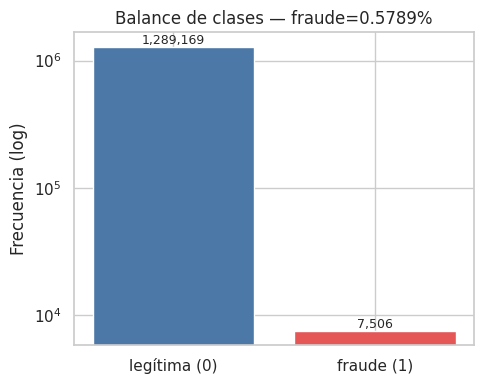

In [2]:
n = len(df)
n_fraud = int(df['is_fraud'].sum())
fraud_rate = n_fraud / n
print(f'rows={n:,}  fraud={n_fraud:,}  rate={fraud_rate:.4%}')
print(f'imbalance ratio = {(n - n_fraud) / max(n_fraud,1):.1f} : 1')

fig, ax = plt.subplots(figsize=(5, 4))
counts = df['is_fraud'].value_counts().sort_index()
bars = ax.bar(['legítima (0)', 'fraude (1)'], counts.values, color=['#4C78A8', '#E45756'])
for b, v in zip(bars, counts.values):
    ax.text(b.get_x() + b.get_width()/2, v, f'{v:,}', ha='center', va='bottom', fontsize=9)
ax.set_yscale('log'); ax.set_ylabel('Frecuencia (log)')
ax.set_title(f'Balance de clases — fraude={fraud_rate:.4%}')
fig.tight_layout(); fig.savefig(FIG_DIR / '01_class_balance.png', dpi=130); plt.show()


## 2. Distribución de `amt` por clase (escala log)

legit  median=47.28  p95=189.90  max=28948.90
fraud  median=396.50  p95=1083.99  max=1376.04


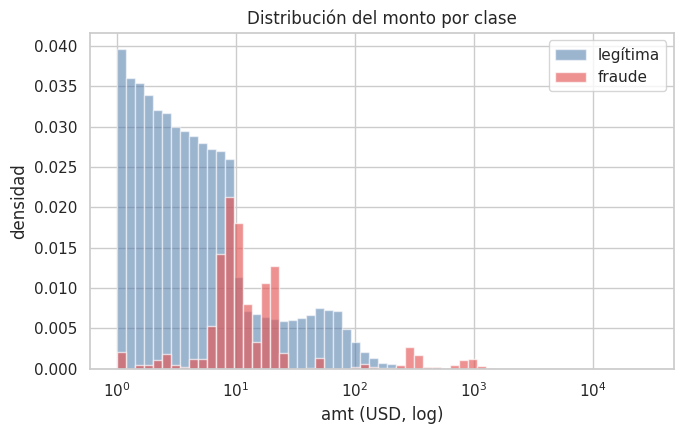

In [3]:
amt_legit = df.loc[df['is_fraud'] == 0, 'amt']
amt_fraud = df.loc[df['is_fraud'] == 1, 'amt']
print('legit  median={:.2f}  p95={:.2f}  max={:.2f}'.format(amt_legit.median(), amt_legit.quantile(.95), amt_legit.max()))
print('fraud  median={:.2f}  p95={:.2f}  max={:.2f}'.format(amt_fraud.median(), amt_fraud.quantile(.95), amt_fraud.max()))

fig, ax = plt.subplots(figsize=(7, 4.5))
bins = np.logspace(np.log10(max(df['amt'].min(), 0.5)), np.log10(df['amt'].max()), 60)
ax.hist(amt_legit, bins=bins, alpha=0.55, label='legítima', color='#4C78A8', density=True)
ax.hist(amt_fraud, bins=bins, alpha=0.65, label='fraude',   color='#E45756', density=True)
ax.set_xscale('log'); ax.set_xlabel('amt (USD, log)'); ax.set_ylabel('densidad')
ax.set_title('Distribución del monto por clase')
ax.legend(); fig.tight_layout(); fig.savefig(FIG_DIR / '02_amt_by_class.png', dpi=130); plt.show()


## 3. Distribución horaria y diaria del fraude

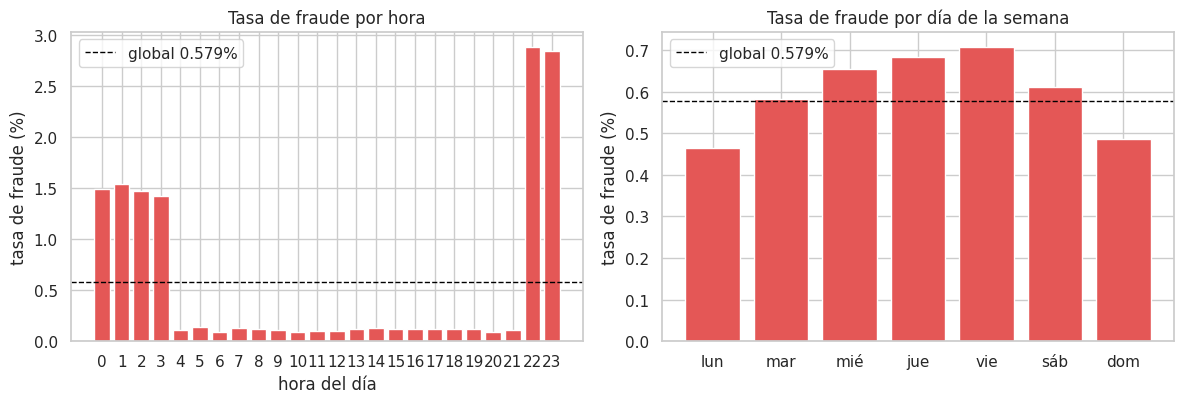

,fraud_rate,sum,count
hour,,,
0,0.014940,635,42502
1,0.015349,658,42869
2,0.014652,625,42656
3,0.014239,609,42769
4,0.001099,46,41863
5,0.001423,60,42171
6,0.000946,40,42300
7,0.001327,56,42203
8,0.001153,49,42505


In [4]:
by_hour = df.groupby('hour')['is_fraud'].agg(['mean','sum','count']).rename(columns={'mean':'fraud_rate'})
by_dow  = df.groupby('dow')['is_fraud'].agg(['mean','sum','count']).rename(columns={'mean':'fraud_rate'})

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].bar(by_hour.index, by_hour['fraud_rate']*100, color='#E45756')
axes[0].axhline(fraud_rate*100, ls='--', color='black', lw=1, label=f'global {fraud_rate*100:.3f}%')
axes[0].set_xlabel('hora del día'); axes[0].set_ylabel('tasa de fraude (%)')
axes[0].set_title('Tasa de fraude por hora'); axes[0].set_xticks(range(0,24)); axes[0].legend()

dow_labels = ['lun','mar','mié','jue','vie','sáb','dom']
axes[1].bar(dow_labels, by_dow['fraud_rate']*100, color='#E45756')
axes[1].axhline(fraud_rate*100, ls='--', color='black', lw=1, label=f'global {fraud_rate*100:.3f}%')
axes[1].set_ylabel('tasa de fraude (%)'); axes[1].set_title('Tasa de fraude por día de la semana'); axes[1].legend()
fig.tight_layout(); fig.savefig(FIG_DIR / '03_temporal_fraud_rate.png', dpi=130); plt.show()
by_hour


## 4. Top categorías por tasa de fraude

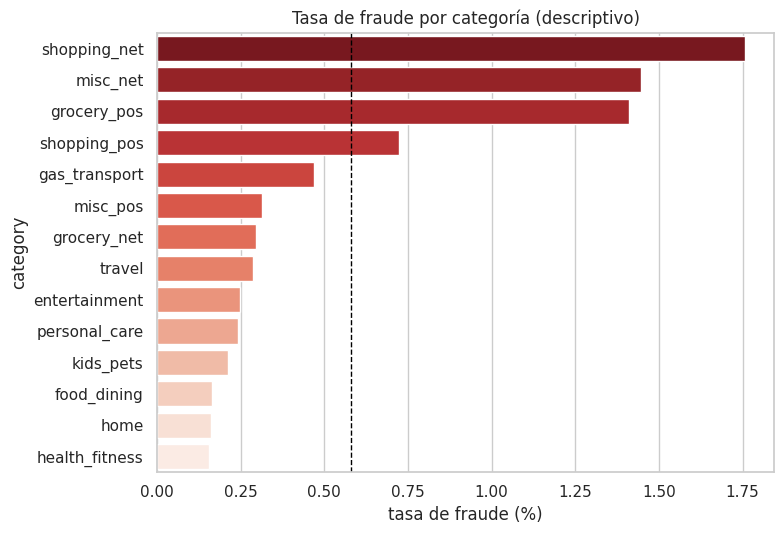

,fraud_rate,sum,count
category,,,
shopping_net,0.017561,1713,97543
misc_net,0.014458,915,63287
grocery_pos,0.014098,1743,123638
shopping_pos,0.007225,843,116672
gas_transport,0.004694,618,131659
misc_pos,0.003139,250,79655
grocery_net,0.002948,134,45452
travel,0.002864,116,40507
entertainment,0.002478,233,94014


In [5]:
by_cat = (df.groupby('category')['is_fraud']
            .agg(['mean','sum','count']).rename(columns={'mean':'fraud_rate'})
            .sort_values('fraud_rate', ascending=False))

fig, ax = plt.subplots(figsize=(8, 5.5))
sns.barplot(x=by_cat['fraud_rate']*100, y=by_cat.index,
            hue=by_cat.index, palette='Reds_r', legend=False, ax=ax)
ax.axvline(fraud_rate*100, ls='--', color='black', lw=1)
ax.set_xlabel('tasa de fraude (%)'); ax.set_ylabel('category')
ax.set_title('Tasa de fraude por categoría (descriptivo)')
fig.tight_layout(); fig.savefig(FIG_DIR / '04_category_fraud_rate.png', dpi=130); plt.show()
by_cat


## 5. Distancia haversine titular ↔ comercio por clase

Distancia entre `(lat, long)` del titular y `(merch_lat, merch_long)` del comercio.

legit  median=78.2  mean=76.1  p95=120.5
fraud  median=77.9  mean=76.3  p95=120.2


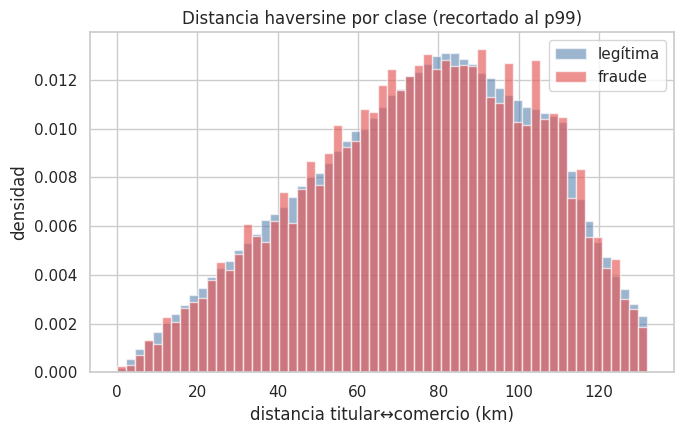

In [6]:
def haversine_km(lat1, lon1, lat2, lon2):
    r = 6371.0088
    lat1r, lat2r = np.radians(lat1), np.radians(lat2)
    dlat = lat2r - lat1r
    dlon = np.radians(lon2 - lon1)
    a = np.sin(dlat/2.0)**2 + np.cos(lat1r)*np.cos(lat2r)*np.sin(dlon/2.0)**2
    return 2.0 * r * np.arcsin(np.sqrt(a))

df['distance_km'] = haversine_km(df['lat'].to_numpy(), df['long'].to_numpy(),
                                 df['merch_lat'].to_numpy(), df['merch_long'].to_numpy())

dist_legit = df.loc[df['is_fraud']==0, 'distance_km']
dist_fraud = df.loc[df['is_fraud']==1, 'distance_km']
print('legit  median={:.1f}  mean={:.1f}  p95={:.1f}'.format(dist_legit.median(), dist_legit.mean(), dist_legit.quantile(.95)))
print('fraud  median={:.1f}  mean={:.1f}  p95={:.1f}'.format(dist_fraud.median(), dist_fraud.mean(), dist_fraud.quantile(.95)))

fig, ax = plt.subplots(figsize=(7, 4.5))
bins = np.linspace(0, max(dist_legit.quantile(.99), dist_fraud.quantile(.99)), 60)
ax.hist(dist_legit, bins=bins, alpha=0.55, label='legítima', color='#4C78A8', density=True)
ax.hist(dist_fraud, bins=bins, alpha=0.65, label='fraude',   color='#E45756', density=True)
ax.set_xlabel('distancia titular↔comercio (km)'); ax.set_ylabel('densidad')
ax.set_title('Distancia haversine por clase (recortado al p99)')
ax.legend(); fig.tight_layout(); fig.savefig(FIG_DIR / '05_distance_by_class.png', dpi=130); plt.show()


## 6. Mapa de calor de fraude por estado (≥1000 tx)

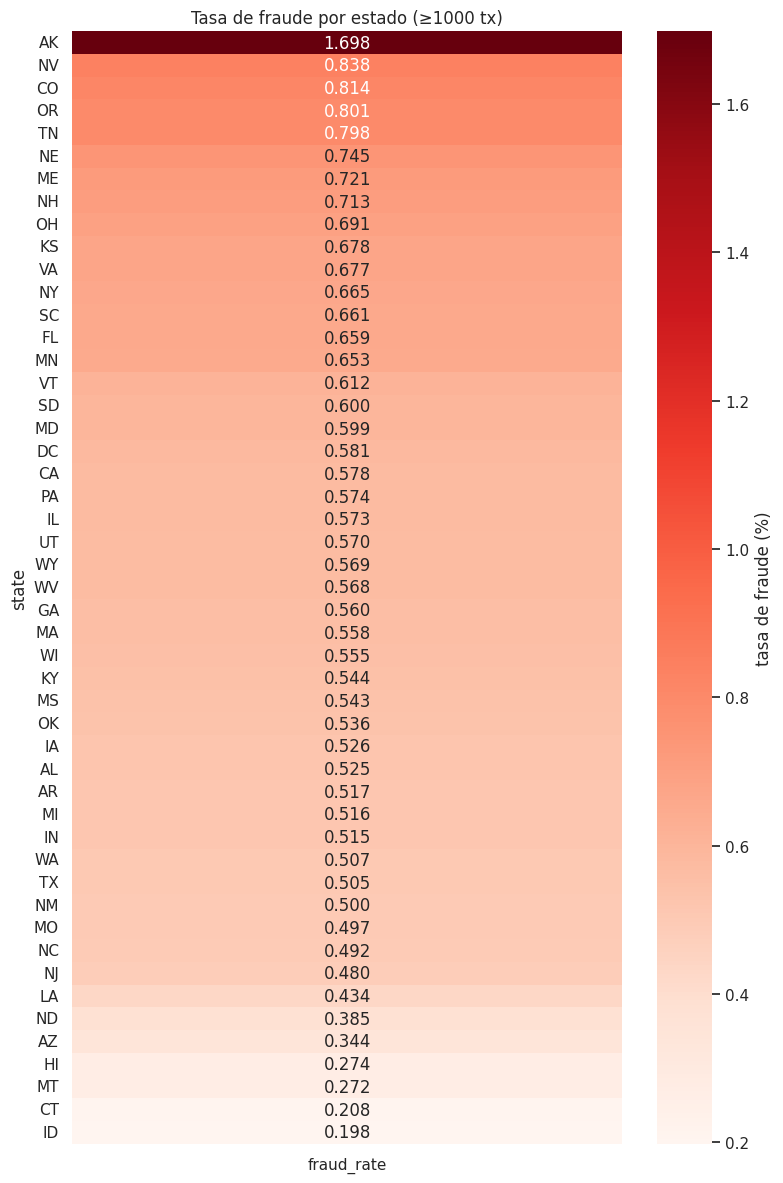

,fraud_rate,sum,count
state,,,
AK,0.016981,36,2120
NV,0.008382,47,5607
CO,0.008141,113,13880
OR,0.008012,149,18597
TN,0.007975,140,17554
NE,0.007448,180,24168
ME,0.007210,119,16505
NH,0.007127,59,8278
OH,0.006906,321,46480


In [7]:
by_state = (df.groupby('state')['is_fraud']
              .agg(['mean','sum','count']).rename(columns={'mean':'fraud_rate'})
              .sort_values('fraud_rate', ascending=False))
by_state_filt = by_state[by_state['count'] >= 1000].copy()

fig, ax = plt.subplots(figsize=(8, 12))
sns.heatmap(by_state_filt[['fraud_rate']]*100, annot=True, fmt='.3f',
            cmap='Reds', cbar_kws={'label': 'tasa de fraude (%)'}, ax=ax)
ax.set_title('Tasa de fraude por estado (≥1000 tx)'); ax.set_xlabel('')
fig.tight_layout(); fig.savefig(FIG_DIR / '06_state_fraud_heatmap.png', dpi=130); plt.show()
by_state_filt.head(10)


## 7. Análisis de `cc_num`

`cc_num` es la **clave de agregación**, no una feature. Acá miramos
volumen por tarjeta y qué fracción concentra fraude — esto motiva las
features rolling/agregadas en Fase 2.

tarjetas únicas: 983
tarjetas con ≥1 fraude: 762 (77.52%)
tx/tarjeta: median=1054  p95=2922  max=3123


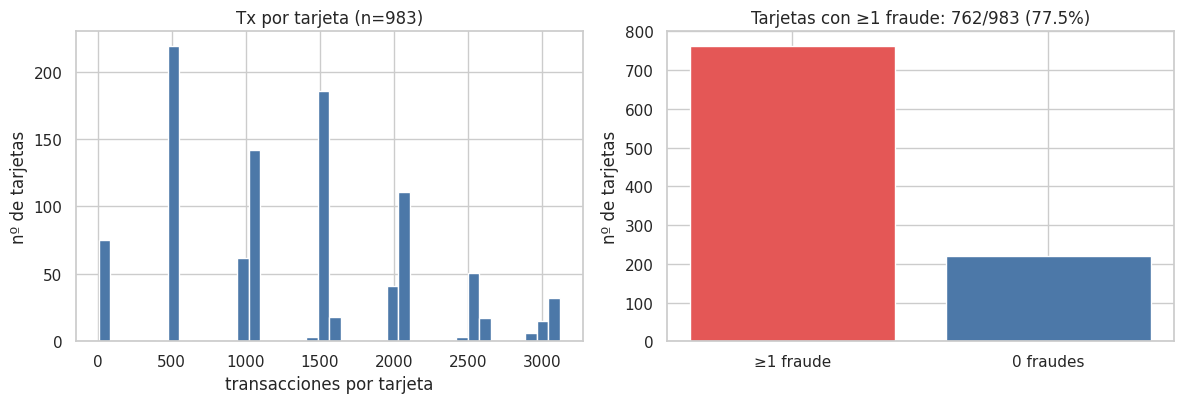

,tx,fraud_tx,any_fraud
count,983.000000,983.000000,983.000000
mean,1319.099695,7.635809,0.775178
std,812.235900,4.870588,0.417678
min,7.000000,0.000000,0.000000
25%,525.000000,4.000000,1.000000
50%,1054.000000,9.000000,1.000000
75%,2025.000000,11.000000,1.000000
max,3123.000000,19.000000,1.000000


In [8]:
by_card = df.groupby('cc_num').agg(tx=('is_fraud','size'), fraud_tx=('is_fraud','sum'))
by_card['any_fraud'] = (by_card['fraud_tx'] > 0).astype(int)

n_cards = len(by_card)
n_fraud_cards = int(by_card['any_fraud'].sum())
print(f'tarjetas únicas: {n_cards}')
print(f'tarjetas con ≥1 fraude: {n_fraud_cards} ({n_fraud_cards/n_cards:.2%})')
print('tx/tarjeta: median={:.0f}  p95={:.0f}  max={}'.format(
    by_card['tx'].median(), by_card['tx'].quantile(.95), by_card['tx'].max()))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].hist(by_card['tx'], bins=40, color='#4C78A8')
axes[0].set_xlabel('transacciones por tarjeta'); axes[0].set_ylabel('nº de tarjetas')
axes[0].set_title(f'Tx por tarjeta (n={n_cards})')

pct = n_fraud_cards / n_cards * 100
axes[1].bar(['≥1 fraude', '0 fraudes'],
            [n_fraud_cards, n_cards - n_fraud_cards],
            color=['#E45756', '#4C78A8'])
axes[1].set_ylabel('nº de tarjetas')
axes[1].set_title(f'Tarjetas con ≥1 fraude: {n_fraud_cards}/{n_cards} ({pct:.1f}%)')
fig.tight_layout(); fig.savefig(FIG_DIR / '07_card_analysis.png', dpi=130); plt.show()
by_card.describe()


## 8. `merchant` — cardinalidad y tasa de fraude

`merchant` no estaba en el plan inicial. Lo medimos acá porque en fraud
detection real es uno de los predictores más fuertes.

cardinalidad: 693 comercios
count median=1863, p5=825
spread top1 / bottom-no-cero: 66x
comercios con 0 fraudes: 14


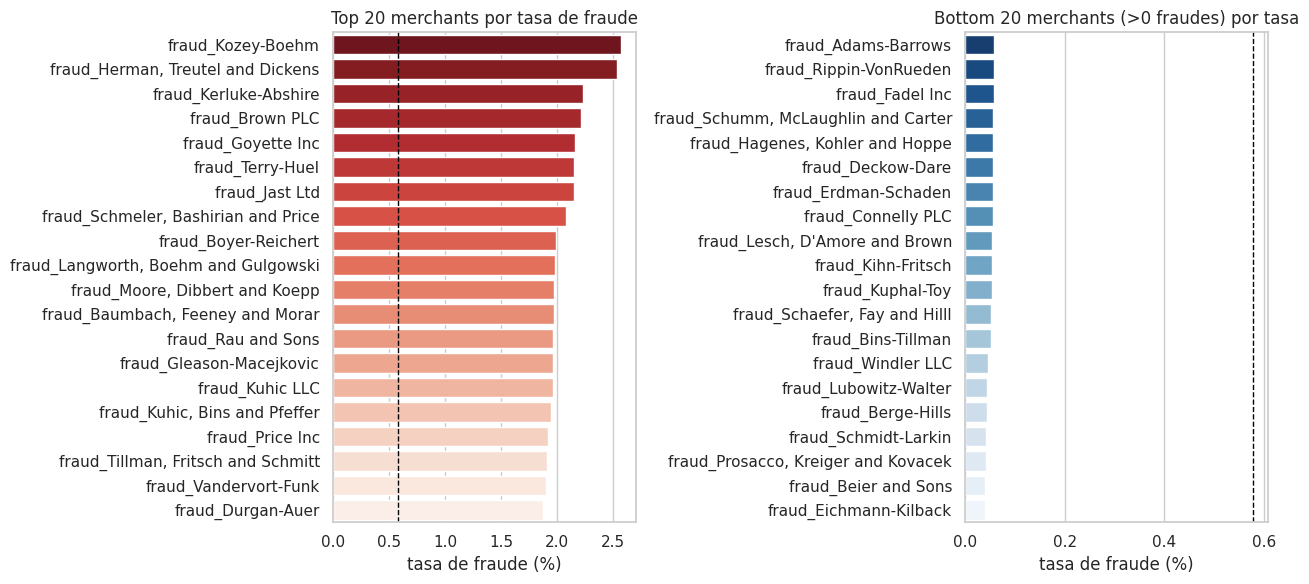

In [9]:
by_merchant = (df.groupby('merchant')['is_fraud']
                  .agg(['mean', 'sum', 'count'])
                  .rename(columns={'mean': 'fraud_rate'})
                  .sort_values('fraud_rate', ascending=False))

print(f'cardinalidad: {len(by_merchant)} comercios')
print(f'count median={by_merchant["count"].median():.0f}, p5={by_merchant["count"].quantile(.05):.0f}')
print(f'spread top1 / bottom-no-cero: '
      f'{by_merchant["fraud_rate"].iloc[0] / max(by_merchant[by_merchant["fraud_rate"]>0]["fraud_rate"].iloc[-1], 1e-9):.0f}x')
print(f'comercios con 0 fraudes: {(by_merchant["fraud_rate"]==0).sum()}')

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
top20 = by_merchant.head(20)
bot20 = by_merchant[by_merchant['fraud_rate'] > 0].tail(20)
sns.barplot(x=top20['fraud_rate']*100, y=top20.index,
            hue=top20.index, palette='Reds_r', legend=False, ax=axes[0])
axes[0].axvline(fraud_rate*100, ls='--', color='black', lw=1)
axes[0].set_title('Top 20 merchants por tasa de fraude')
axes[0].set_xlabel('tasa de fraude (%)'); axes[0].set_ylabel('')

sns.barplot(x=bot20['fraud_rate']*100, y=bot20.index,
            hue=bot20.index, palette='Blues_r', legend=False, ax=axes[1])
axes[1].axvline(fraud_rate*100, ls='--', color='black', lw=1)
axes[1].set_title('Bottom 20 merchants (>0 fraudes) por tasa')
axes[1].set_xlabel('tasa de fraude (%)'); axes[1].set_ylabel('')

fig.tight_layout(); fig.savefig(FIG_DIR / '08_merchant_top_bottom.png', dpi=130); plt.show()


## 9. Edad del titular (derivada de `dob`)

Edad en años calculada como `(trans_date_trans_time - dob)`. Permite ver
si hay segmentos demográficos más expuestos.

legit  median=44.0  mean=46.0
fraud  median=47.8  mean=48.8

tasa por bucket:
age_bucket
<25      0.628
25-35    0.483
35-50    0.456
50-65    0.741
65+      0.743
Name: fraud_rate, dtype: float64


/tmp/ipykernel_18018/2670755146.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([age_legit, age_fraud], labels=['legítima', 'fraude'],


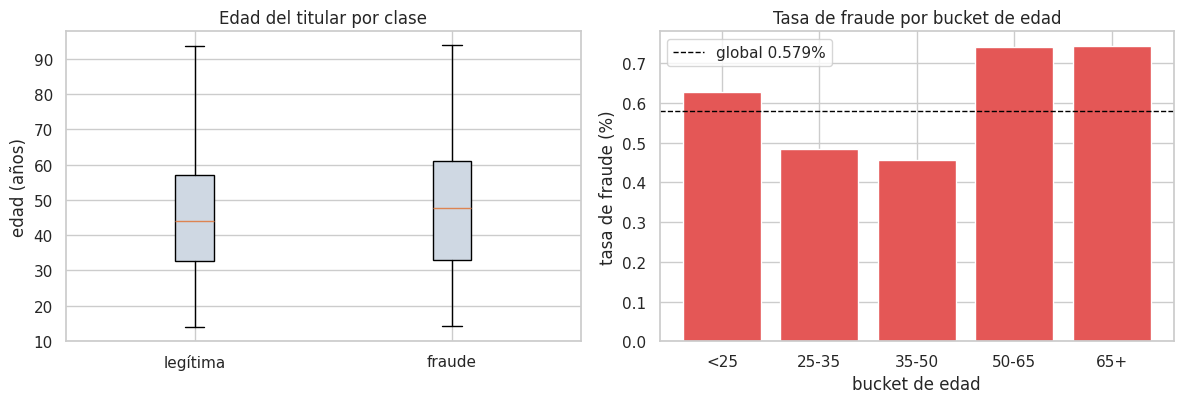

In [10]:
age_legit = df.loc[df['is_fraud']==0, 'age']
age_fraud = df.loc[df['is_fraud']==1, 'age']
print(f'legit  median={age_legit.median():.1f}  mean={age_legit.mean():.1f}')
print(f'fraud  median={age_fraud.median():.1f}  mean={age_fraud.mean():.1f}')

df['age_bucket'] = pd.cut(df['age'], bins=[0, 25, 35, 50, 65, 120],
                           labels=['<25', '25-35', '35-50', '50-65', '65+'])
by_age = df.groupby('age_bucket', observed=True)['is_fraud'].agg(['mean', 'count']).rename(columns={'mean':'fraud_rate'})
print('\ntasa por bucket:')
print((by_age['fraud_rate'] * 100).round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].boxplot([age_legit, age_fraud], labels=['legítima', 'fraude'],
                showfliers=False, patch_artist=True,
                boxprops=dict(facecolor='#cfd8e3'))
axes[0].set_ylabel('edad (años)'); axes[0].set_title('Edad del titular por clase')

axes[1].bar(by_age.index.astype(str), by_age['fraud_rate']*100, color='#E45756')
axes[1].axhline(fraud_rate*100, ls='--', color='black', lw=1, label=f'global {fraud_rate*100:.3f}%')
axes[1].set_ylabel('tasa de fraude (%)'); axes[1].set_xlabel('bucket de edad')
axes[1].set_title('Tasa de fraude por bucket de edad'); axes[1].legend()
fig.tight_layout(); fig.savefig(FIG_DIR / '09_age_by_class.png', dpi=130); plt.show()


## 10. `city_pop` — resultado negativo

Para cerrar, miramos si la población de la ciudad del titular separa.
Spoiler: casi no.

In [11]:
df['pop_bucket'] = pd.cut(df['city_pop'],
                           bins=[0, 1_000, 10_000, 100_000, 1_000_000, 50_000_000],
                           labels=['<1k', '1k-10k', '10k-100k', '100k-1M', '1M+'])
by_pop = df.groupby('pop_bucket', observed=True)['is_fraud'].agg(['mean','count']).rename(columns={'mean':'fraud_rate'})
print('city_pop legit median={:.0f}  fraud median={:.0f}'.format(
    df.loc[df.is_fraud==0,'city_pop'].median(), df.loc[df.is_fraud==1,'city_pop'].median()))
print('\ntasa por bucket de población:')
print((by_pop['fraud_rate']*100).round(3))
print(f'spread max/min: {by_pop["fraud_rate"].max() / by_pop["fraud_rate"].min():.2f}x')


city_pop legit median=2456  fraud median=2623

tasa por bucket de población:
pop_bucket
<1k         0.578
1k-10k      0.562
10k-100k    0.555
100k-1M     0.672
1M+         0.591
Name: fraud_rate, dtype: float64
spread max/min: 1.21x


## Hallazgos accionables (resumen)

Ver `reports/eda_report.md` para el detalle. Headlines:

- **Desbalance ~172:1** → `scale_pos_weight` en XGBoost; reportar PR-AUC.
- **`amt`** separa fuerte: log-amt + flags por percentil son útiles.
- **Hora** 22h-02h concentra fraude (5x global).
- **Categorías** `shopping_net`, `misc_net`, `grocery_pos` lideran.
- **`merchant`** ⭐ — 693 comercios, top ~2.5%, 14 con **0% fraude**, spread enorme. Candidato fuerte a target encoding KFold.
- **Edad** — patrón **bimodal**: <25 (0.63%) y 50+ (0.74%) elevados; 25-50 por debajo del global. Feature derivable barata.
- **Distancia haversine cruda no separa**; la geografía sirve sólo
  relativa al comportamiento de cada tarjeta.
- **77.5% de las tarjetas tienen ≥1 fraude** → features rolling por
  `cc_num` (counts/amount stats) son centrales.
- **`city_pop`**: descartado, spread <1.2x.
